# 📊 Toyota Car Data Visualization

This notebook teaches **how to choose and create different plots** for the Toyota dataset.

✅ Matplotlib and Seaborn sections clearly separated
✅ Each plot has:
- 📌 *What it is*
- ✅ *When/Where to use it*

✅ Covers **ALL these plots**:
- 📊 Bar Chart
- 📈 Line Plot
- 🟢 Scatter Plot
- 📦 Box Plot
- 📊 Pie Chart
- 🔥 Heatmap
- 🧩 Area Chart
- 🔗 Pairplot


In [1]:
# 📌 Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")


## 📌 Load Data

We load **Toyota (2).csv** with special characters as NaN and drop missing values.


In [2]:
from pathlib import Path
base_dir = Path.cwd()
df = pd.read_csv(base_dir / "DATA" / "Toyota.csv", index_col=0, na_values=["??","????"])
df.dropna(inplace=True)
df.head()


,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23.0,46986.0,Diesel,90.0,1.0,0,2000,three,1165
1,13750,23.0,72937.0,Diesel,90.0,1.0,0,2000,3,1165
3,14950,26.0,48000.0,Diesel,90.0,0.0,0,2000,3,1165
4,13750,30.0,38500.0,Diesel,90.0,0.0,0,2000,3,1170
5,12950,32.0,61000.0,Diesel,90.0,0.0,0,2000,3,1170


## 📌 Data Overview

Quick check of structure and summary statistics.


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      1096 non-null   int64  
 1   Age        1096 non-null   float64
 2   KM         1096 non-null   float64
 3   FuelType   1096 non-null   object 
 4   HP         1096 non-null   float64
 5   MetColor   1096 non-null   float64
 6   Automatic  1096 non-null   int64  
 7   CC         1096 non-null   int64  
 8   Doors      1096 non-null   object 
 9   Weight     1096 non-null   int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 94.2+ KB


*   Doors – Currently object, should be integer or categorical. There may be inconsistent formatting (e.g., "3", "three", or float-like "3.0")

In [6]:
df['Doors'].unique()

array([3, 5, 4, 2])

In [8]:
df['Doors'] = df['Doors'].replace(
    {'two': 2, 'three': 3, 'four': 4, 'five': 5}, regex=True
).astype(int)


In [9]:
print(df['MetColor'].unique())
print(df['Automatic'].unique())

[1. 0.]
[0 1]


In [10]:
df['MetColor'] = df['MetColor'].astype('str')
df['Automatic'] = df['Automatic'].astype('str')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      1096 non-null   int64  
 1   Age        1096 non-null   float64
 2   KM         1096 non-null   float64
 3   FuelType   1096 non-null   object 
 4   HP         1096 non-null   float64
 5   MetColor   1096 non-null   object 
 6   Automatic  1096 non-null   object 
 7   CC         1096 non-null   int64  
 8   Doors      1096 non-null   int64  
 9   Weight     1096 non-null   int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 94.2+ KB


In [12]:
df.describe()


,Price,Age,KM,HP,CC,Doors,Weight
count,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,10735.937044,55.661496,69268.826642,101.806569,1568.863139,4.062044,1073.416971
std,3636.716945,18.699777,38070.667467,15.034116,184.386960,0.956488,51.812821
min,4350.000000,1.000000,1.000000,69.000000,1300.000000,2.000000,1000.000000
25%,8450.000000,43.000000,43590.500000,90.000000,1400.000000,3.000000,1045.000000
50%,9900.000000,60.000000,63393.500000,110.000000,1600.000000,4.000000,1070.000000
75%,11950.000000,70.000000,88031.750000,110.000000,1600.000000,5.000000,1090.000000
max,31275.000000,80.000000,243000.000000,192.000000,2000.000000,5.000000,1615.000000


## 📌 Understanding Variable Types in Our Dataset

### 🟡 **Categorical Variables**
- Describe *categories* or *groups*
- Examples:
  - FuelType (Petrol, Diesel, CNG)
  - Automatic (0/1)
  - Doors (can be treated categorical)

✅ Best visualizations:
- Bar plots
- Count plots
- Pie charts
- Grouped boxplots

---

### 🟣 **Numerical Variables**
- Continuous or discrete *numbers*
- Examples:
  - Age (months)
  - Price (Euros)
  - KM (Kilometers)
  - HP (Horse Power)

✅ Best visualizations:
- Scatter plots
- Line plots
- Histograms
- Boxplots
- Area charts
- Heatmaps
- Pairplots


# 🎨 1️⃣ Matplotlib Visualizations


## 🟢 Scatter Plot

**What is it?**
- Shows individual data points on X and Y axes.

**When/Where to Use:**  
- For visualizing *correlations* between two numerical variables.


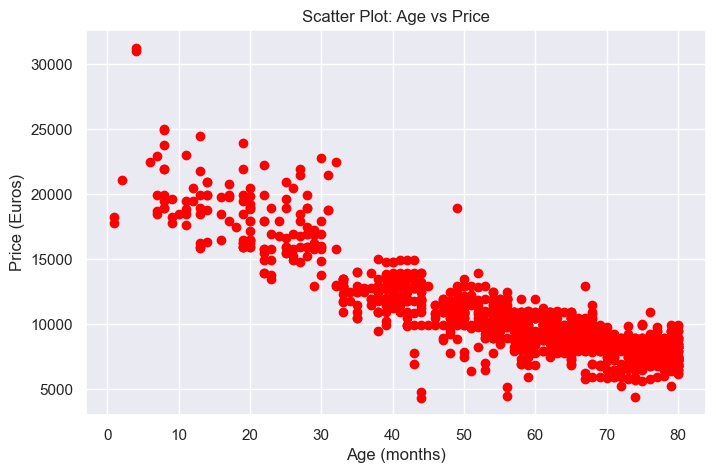

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['Price'], color='red')
plt.title('Scatter Plot: Age vs Price')
plt.xlabel('Age (months)')
plt.ylabel('Price (Euros)')
plt.show()



**Inference:**  
- The scatter plot shows a clear negative relationship between Age and Price. As the car's age increases, its price drops significantly, illustrating typical depreciation trends seen in used cars.


## 📈 Line Plot

**What is it?**
- Connects data points with lines to show *trends over an ordered axis*.

**When/Where to Use:**  
- Best for *time series* or sequential data.


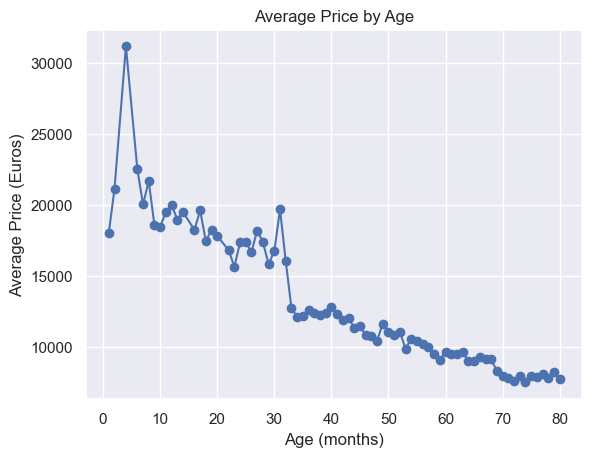

In [14]:
age_price = df.groupby('Age')['Price'].mean().sort_index()
age_price.plot(kind='line', marker='o')
plt.title('Average Price by Age')
plt.xlabel('Age (months)')
plt.ylabel('Average Price (Euros)')
plt.show()



**Inference:**  
- This line plot of average Price by Age reveals a consistent downward trend. It emphasizes that as vehicles age, their average market value declines, confirming the expected depreciation pattern in the dataset.

## 📊 Bar Plot

**What is it?**
- Compares values across categories.

**When/Where to Use:**  
- Best for *categorical* variables.


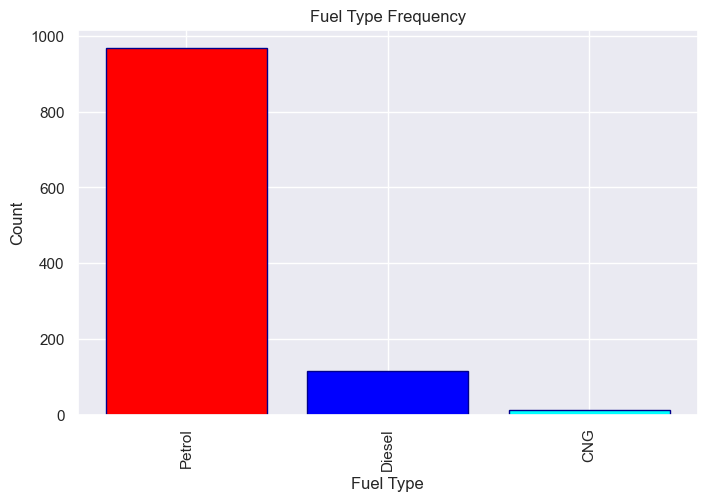

In [15]:
fuel_counts = df['FuelType'].value_counts()
index = np.arange(len(fuel_counts))
plt.figure(figsize=(8,5))
plt.bar(index, fuel_counts.values, color=['red','blue','cyan'], edgecolor='darkblue')
plt.title('Fuel Type Frequency')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.xticks(index, fuel_counts.index, rotation=90)
plt.show()



**Inference:**  
- The bar plot shows Petrol cars dominate the dataset, followed by Diesel and very few CNG vehicles. This distribution highlights the preference for Petrol vehicles in the sample.
python
Copy
Edit


## 📊 Pie Chart

**What is it?**
- Shows *parts of a whole*.

**When/Where to Use:**  
- Good for *showing category proportions*.


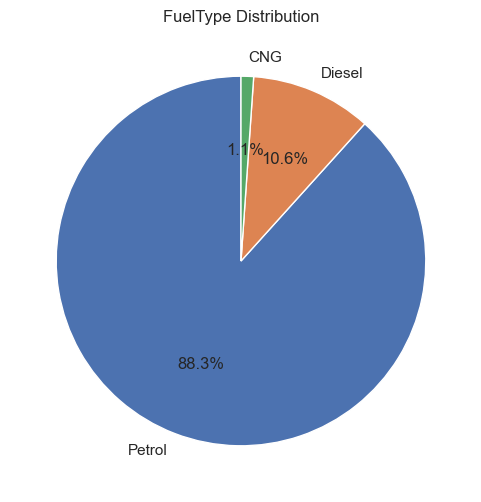

In [16]:
fuel_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(6,6))
plt.title('FuelType Distribution')
plt.ylabel('')
plt.show()



**Inference:**  
Petrol cars dominate the dataset, making up 88.3% of all entries.

Diesel vehicles account for 10.6%, a much smaller share.

CNG vehicles are extremely rare, representing only 1.1%.


## 📊 Histogram

**What is it?**
- Shows distribution of a single numerical variable.

**When/Where to Use:**  
- To see *spread*, *skew*, *outliers*.


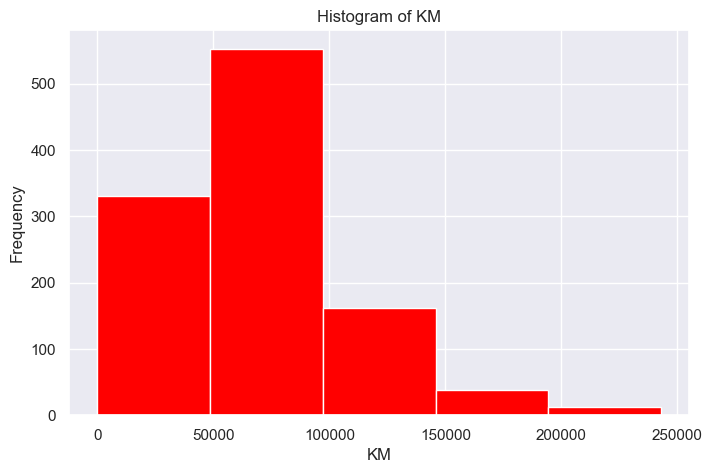

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df['KM'], bins=5, color='red', edgecolor='white')
plt.title('Histogram of KM')
plt.xlabel('KM')
plt.ylabel('Frequency')
plt.show()


**Inference:**  
- Most vehicles have low to moderate KM values:

- The largest number of cars fall in the 50,000–100,000 KM range.

# 🎨 2️⃣ Seaborn Visualizations


## 🟢 Regression Scatter Plot

**What is it?**
- Scatter plot with regression line.

**When/Where to Use:**  
- To see *relationship* and *trend estimation*.


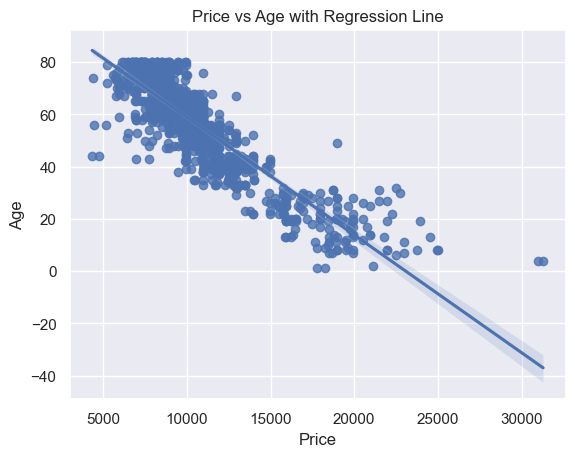

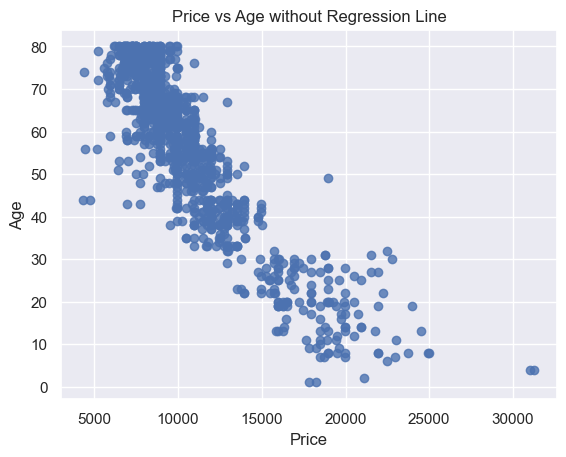

In [18]:
sns.regplot(x='Price', y='Age', data=df)
plt.title('Price vs Age with Regression Line')
plt.show()

sns.regplot(x='Price', y='Age', data=df, fit_reg=False)
plt.title('Price vs Age without Regression Line')
plt.show()



**Inference:**  
- The regression scatter plot confirms a strong negative correlation. As Age increases, Price decreases in a fairly linear way. The fitted line quantifies this trend, helping predict price depreciation with age.


## 🟢 lmplot with Hue

**What is it?**
- Scatter plot with *categories highlighted by color*.

**When/Where to Use:**  
- Best for *comparing groups* in relationships.


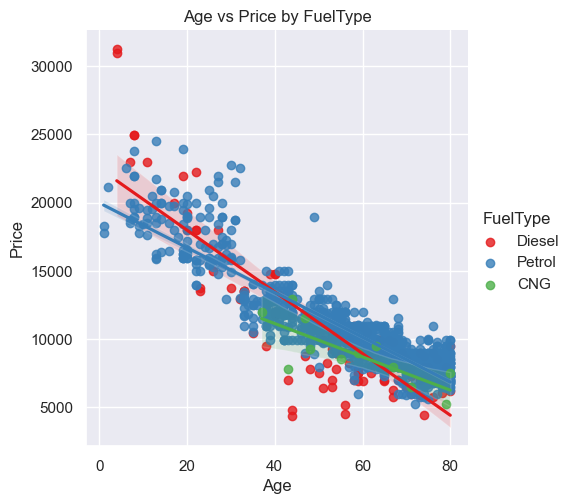

In [19]:
sns.lmplot(x='Age', y='Price', data=df, hue='FuelType', fit_reg=True, palette='Set1')
plt.title('Age vs Price by FuelType')
plt.show()

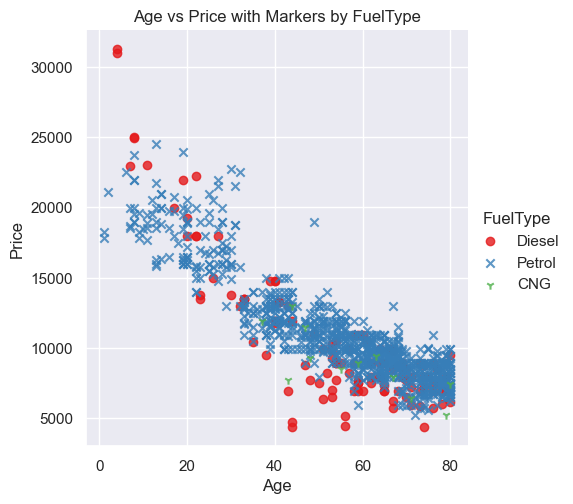

In [20]:
sns.lmplot(x='Age', y='Price', data=df, hue='FuelType', fit_reg=False,
           markers=["o", "x", "1"], palette="Set1")
plt.title('Age vs Price with Markers by FuelType')
plt.show()


**Inference:**  
- By adding FuelType as hue, we see the depreciation trend across categories. Petrol, Diesel, and CNG vehicles all show decreasing price with age, but the spread and clustering reveal subtle differences in their resale value trends.


## 📊 Count Plot

**What is it?**
- Bar plot showing count of categories.

**When/Where to Use:**  
- Best for *categorical frequency*.


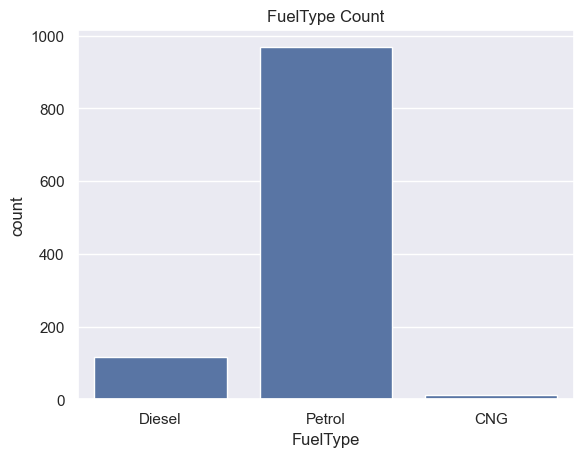

In [21]:
sns.countplot(x='FuelType', data=df)
plt.title('FuelType Count')
plt.show()

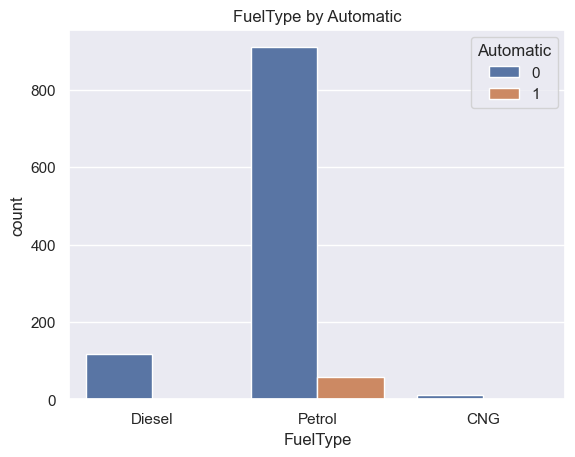

In [22]:
sns.countplot(x='FuelType', hue='Automatic', data=df)
plt.title('FuelType by Automatic')
plt.show()


**Inference:**  
- The count plot again confirms that Petrol cars dominate. The grouped version with Automatic shows that most Petrol cars are manual, revealing transmission preferences tied to fuel type.



## 📊 Histogram with Seaborn

**What is it?**
- Shows distribution, optionally with *density curve*.

**When/Where to Use:**  
- For exploring *numerical variable shape*.


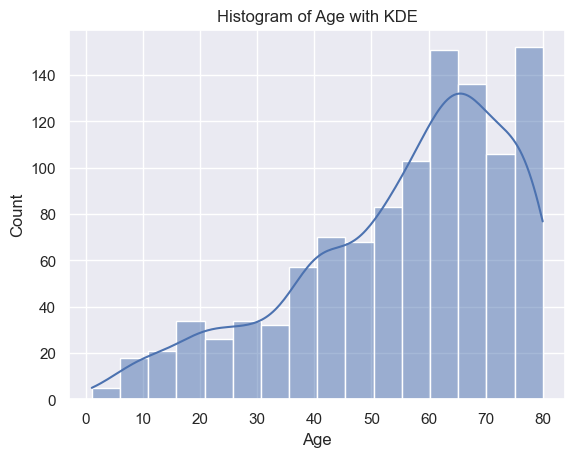

In [23]:
sns.histplot(df['Age'], kde=True)
plt.title('Histogram of Age with KDE')
plt.show()

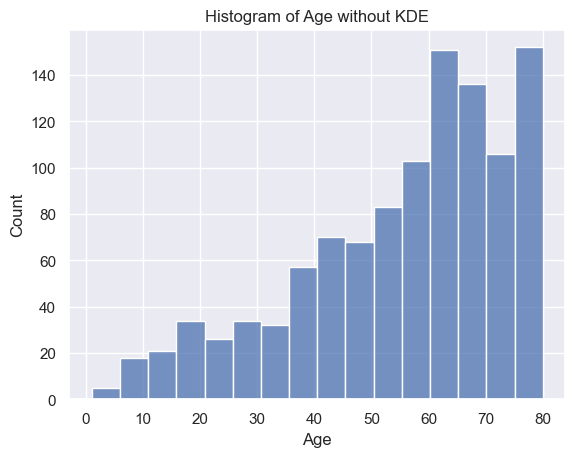

In [24]:
sns.histplot(df['Age'], kde=False)
plt.title('Histogram of Age without KDE')
plt.show()


**Inference:**  
- The histogram for Age shows a peak at older ages. The KDE curve visualizes this skew clearly.

## 📦 Boxplots

**What is it?**
- Shows *median, quartiles, and outliers*.

**When/Where to Use:**  
- Best for *comparing distributions*.


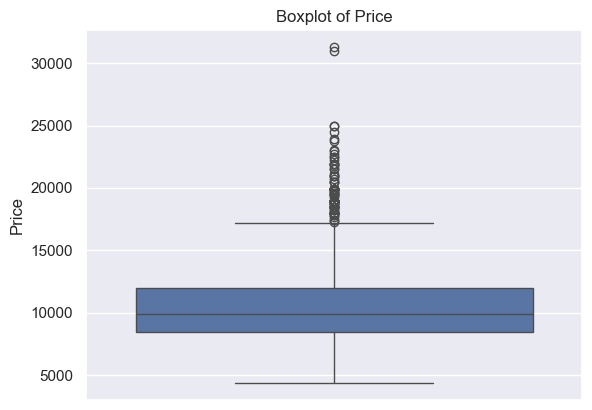

In [25]:
sns.boxplot(y='Price', data=df)
plt.title('Boxplot of Price')
plt.show()

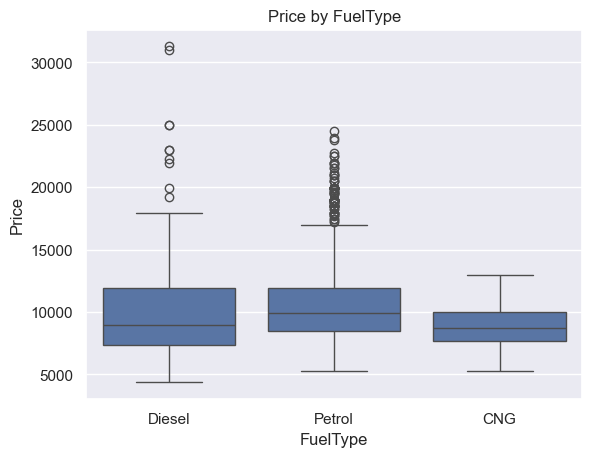

In [26]:
sns.boxplot(x='FuelType', y='Price', data=df)
plt.title('Price by FuelType')
plt.show()

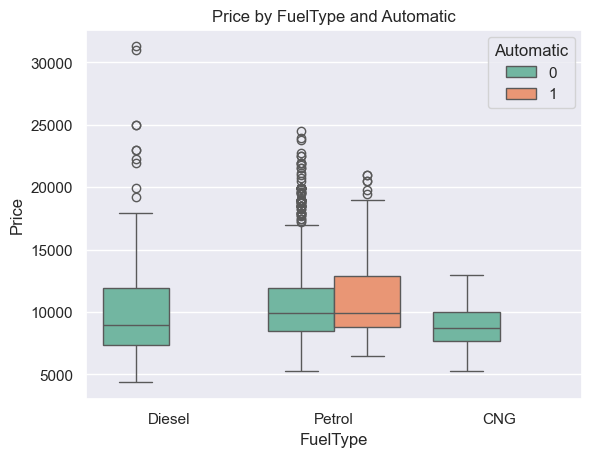

In [27]:
sns.boxplot(x='FuelType', y='Price', hue='Automatic', data=df, palette='Set2')
plt.title('Price by FuelType and Automatic')
plt.show()


**Inference:**  

Petrol has a slightly higher median line than Diesel and CNG.

Diesel is close behind.

CNG has the lowest median.

- Petrol:

The distribution for Petrol cars is more spread out compared to Diesel.

Petrol cars also show several outliers, similar to Diesel, indicating that there are some cars priced much higher than the general trend.

- CNG:
Price for CNG cars is much lower than that for Diesel and Petrol.

The spread of prices for CNG cars is quite compact.

## 📦 Combined Boxplot and Histogram

**What is it?**
- Boxplot + Histogram on shared axis.

**When/Where to Use:**  
- Shows *summary* + *distribution* together.


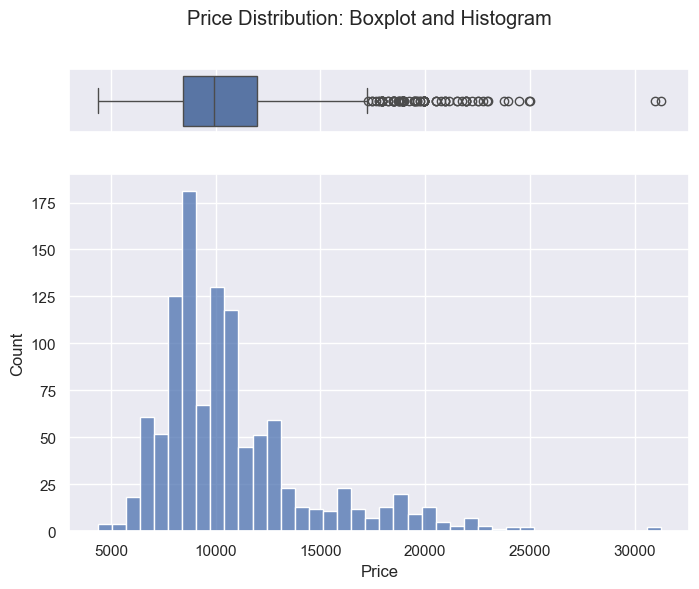

In [28]:
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True,
                                    gridspec_kw={"height_ratios": (.15, .85)},
                                    figsize=(8,6))
sns.boxplot(x=df['Price'], ax=ax_box)
sns.histplot(df['Price'], kde=False, ax=ax_hist)
ax_box.set(xlabel='')
plt.suptitle('Price Distribution: Boxplot and Histogram')
plt.show()



**Inference:**  
- This combined view confirms Price is skewed right. The histogram shows concentration in lower prices, while the boxplot highlights outliers, making the dual visualization very effective for detecting spread and anomalies.


## 🔥 Heatmap

**What is it?**
- Visualizes *correlation matrix*.

**When/Where to Use:**  
- Best for finding *relationships* among many numeric variables.


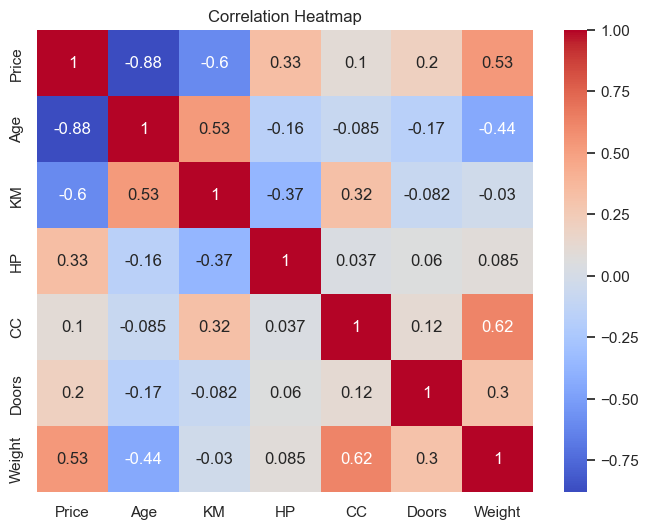

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



**Inference:**  
- The heatmap shows strong negative correlation between Age and Price. KM also has mild negative correlation with Price, while other numerical variables show weaker relationships.

## 🔗 Pairplot

**What is it?**
- Matrix of scatterplots for *all numeric variable pairs*.

**When/Where to Use:**  
- Best for *exploring multiple relationships* at once.


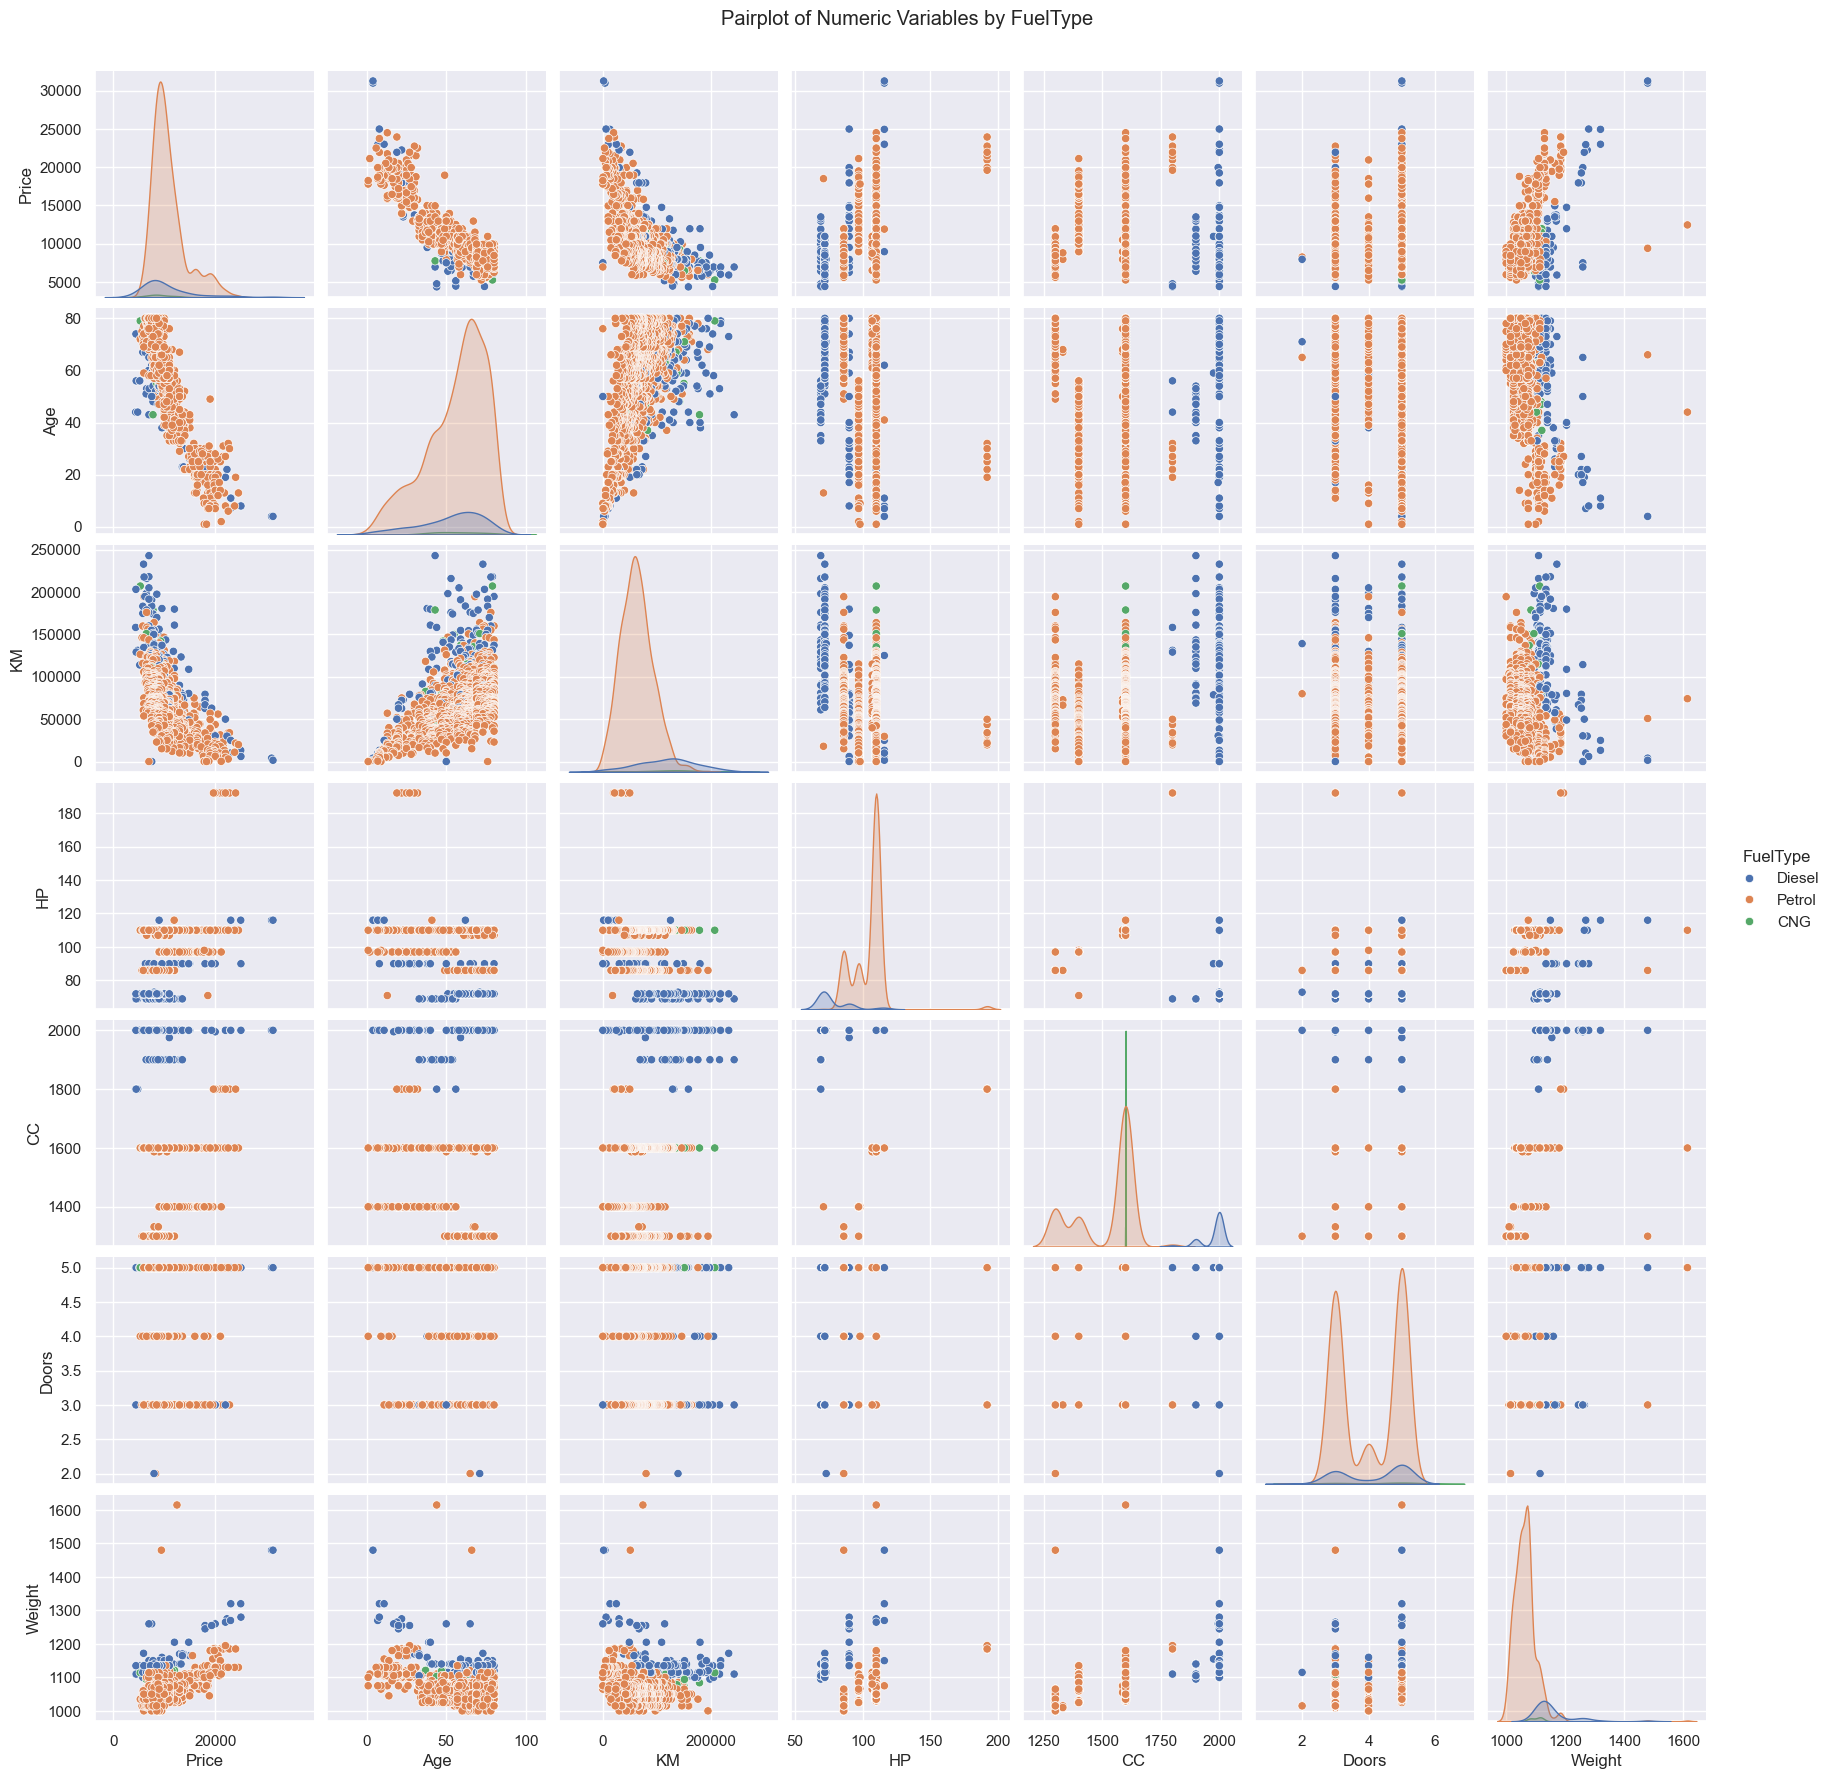

In [30]:
sns.pairplot(df, hue='FuelType')
plt.suptitle('Pairplot of Numeric Variables by FuelType', y=1.02)
plt.show()



**Inference:**  
- The pairplot reveals clear negative trends between Age and Price, and KM and Price. Color-coding by FuelType shows these trends hold across categories, supporting consistent depreciation patterns.


 **Key Takeaways from the Toyota Data**:
- **Depreciation Trend:** Clear negative relationship between Age and Price.
- **Fuel Type Dominance:** Petrol cars make up most of the dataset.
- **KM driven Distribution:** Most vehicles have moderate KM, with a right-skewed distribution.
- **Transmission Patterns:** Manual dominates but varies with FuelType.
- **Price Outliers:** Boxplots show right-skew and multiple outliers, emphasizing pricing variation.
